# 解說
這一篇承襲20260318_code資料夾裡的 "OU_LossIndecator-2D Spiral_betaSigmaConst" 這一篇。  
找到具體例子驗證:  
* $I_{DSM}$ 小 $\Rightarrow$ 圖好  
* $I_{DSM}$ 大 $\Rightarrow$ 圖差  
  
針對這個例題，我們將以五組beta以及其對應的t去做比較loss與$I_{DSM}$的結果

# Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sample_p0_mix(n_points=2500):
    theta = np.sqrt(np.random.rand(n_points)) * 6 * np.pi # 角度
    r = 1 * theta 
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    data = np.stack([x, y], axis=1) + np.random.randn(n_points, 2) * 0.1
    return data

In [2]:
# --- 定義五組實驗參數 ---
beta_list = [1.0]
target_constant = 10.0
sigma = 5.0  # 保持固定

# 建立一個字典來存儲每一組對應的 T (時間終點)
configs = {b: target_constant / b for b in beta_list}

# 原本的 mu_t, std_t 建議寫成函數，方便在訓練迴圈中調用
def get_diffused_sample(x0, t, beta, sigma):
    # t 可以是一個 tensor (batch_size, 1)
    mu_t = np.exp(-beta * t) * x0
    var_t = (sigma**2 / (2 * beta)) * (1 - np.exp(-2 * beta * t))
    std_t = np.sqrt(var_t)
    eps = np.random.randn(*x0.shape)
    xt = mu_t + std_t * eps
    return xt, std_t, eps

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 256), 
            nn.SiLU(), 
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x, t):
        t_input = t.view(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_input], dim=-1))

In [4]:
def train(model, beta, sigma, T, steps, device):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    loss_his = []
    iDsm_his = []

    model.train() 
    for i in range(steps):
        x0_np = sample_p0_mix(n_points=2500)
        x0 = torch.tensor(x0_np, dtype=torch.float32).to(device)
        
        t = (torch.rand(x0.shape[0]) * T).to(device)
        
        t_view = t.view(-1, 1) 
        mu_t = torch.exp(-beta * t_view) * x0
        
        var_t = (sigma**2 / (2*beta)) * (1 - torch.exp(-2*beta*t_view))
        std_t = torch.sqrt(var_t)
        
        eps = torch.randn_like(x0).to(device)
        xt = mu_t + std_t * eps
        
        optimizer.zero_grad()
        eps_pred = model(xt, t) # model(xt, t)
        
        loss = nn.MSELoss()(eps_pred, eps)
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            inner_product = torch.sum(eps_pred * (eps_pred - eps), dim=1, keepdim=True)
            i_dsm_batch = torch.mean(inner_product / sigma**2)

        loss_his.append(loss.item())
        iDsm_his.append(i_dsm_batch.item())
        
        if i % 100 == 0:
            print(f"Step {i}, Loss: {loss.item():.4f}, Idsm: {i_dsm_batch.item():.4f}")
            
    return loss_his, iDsm_his

device = torch.device("cpu")

# Reverse

---

In [5]:
@torch.no_grad()
def reverse_sample(model, n_samples, beta, sigma, T, dt):
    device = next(model.parameters()).device
    var_T = sigma**2 / (2 * beta)
    x = torch.randn(n_samples, 2).to(device) * np.sqrt(var_T)
    
    ts = np.arange(T, 0, -dt)
    for t_val in ts:
        t_tensor = torch.full((n_samples,), t_val).to(device)
        eps_pred = model(x, t_tensor)
        sigma_t = torch.sqrt((sigma**2 / (2 * beta)) * (1 - torch.exp(torch.tensor(-2 * beta * t_val))))
        score = -eps_pred / (sigma_t + 1e-5)
        
        drift = -beta * x - (sigma**2) * score
        noise = torch.randn_like(x) if t_val > dt else 0
        
        x = x - drift * dt + sigma * np.sqrt(dt) * noise
        
    return x

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

beta_list =[0.1, 0.5, 1.0, 2.0, 5.0]
target_constant = 10.0
sigma_val = 5.0  
train_steps = 2500
sampling_steps = 2500

all_results = {}
gt_data = sample_p0_mix(n_points=2500) # Ground Truth 

for i, b_val in enumerate(beta_list):
    current_T = target_constant / b_val
    print(f"\n>>> 實驗 {i+1}/5: Beta = {b_val}, T = {current_T:.2f}")
    
    model = ScoreNet().to(device)
    loss_h, idsm_h = train(model, beta=b_val, sigma=sigma_val, T=current_T, steps=train_steps, device=device)

    idsm2_val = np.mean(np.abs(idsm_h)) # idsm2_val : 對整個訓練過程的 idsm 取絕對值平均

    gen_samples = reverse_sample(
        model, n_samples=2500, beta=b_val, sigma=sigma_val, 
        T=current_T, dt=current_T/sampling_steps
    )
    
    all_results[b_val] = {
        "loss": loss_h, 
        "idsm": idsm_h, 
        "gen_data": gen_samples.cpu().numpy(),
        "avg_loss": np.mean(loss_h),
        "avg_idsm": np.mean(idsm_h),
        "avg_idsm2": idsm2_val  
    }

    print(f"Beta: {b_val}, Avg I_DSM: {np.mean(idsm_h):.6f}, Avg I_DSM_2: {idsm2_val:.6f}")



>>> 實驗 1/5: Beta = 0.1, T = 100.00
Step 0, Loss: 2.6727, Idsm: 0.1483
Step 100, Loss: 0.0446, Idsm: -0.0004
Step 200, Loss: 0.0413, Idsm: -0.0000
Step 300, Loss: 0.0404, Idsm: -0.0000
Step 400, Loss: 0.0394, Idsm: -0.0001
Step 500, Loss: 0.0368, Idsm: -0.0001
Step 600, Loss: 0.0395, Idsm: 0.0000
Step 700, Loss: 0.0386, Idsm: 0.0004
Step 800, Loss: 0.0383, Idsm: -0.0002
Step 900, Loss: 0.0427, Idsm: 0.0003
Step 1000, Loss: 0.0424, Idsm: -0.0000
Step 1100, Loss: 0.0383, Idsm: 0.0001
Step 1200, Loss: 0.0430, Idsm: 0.0002
Step 1300, Loss: 0.0441, Idsm: 0.0005
Step 1400, Loss: 0.0519, Idsm: -0.0002
Step 1500, Loss: 0.0402, Idsm: -0.0003
Step 1600, Loss: 0.0427, Idsm: -0.0002
Step 1700, Loss: 0.0423, Idsm: 0.0001
Step 1800, Loss: 0.0366, Idsm: -0.0001
Step 1900, Loss: 0.0362, Idsm: -0.0000
Step 2000, Loss: 0.0436, Idsm: 0.0001
Step 2100, Loss: 0.0373, Idsm: 0.0005
Step 2200, Loss: 0.0439, Idsm: -0.0003
Step 2300, Loss: 0.0465, Idsm: -0.0002
Step 2400, Loss: 0.0347, Idsm: -0.0000
Beta: 0.1, 

Beta 0.1: Avg Loss = 0.0507, Avg IDSM = 0.00068347, Avg IDSM_2 (Abs) = 0.00018013
Beta 0.5: Avg Loss = 0.0859, Avg IDSM = 0.00003023, Avg IDSM_2 (Abs) = 0.00047038
Beta 1.0: Avg Loss = 0.1115, Avg IDSM = 0.00002136, Avg IDSM_2 (Abs) = 0.00061298
Beta 2.0: Avg Loss = 0.1409, Avg IDSM = 0.00001748, Avg IDSM_2 (Abs) = 0.00071034
Beta 5.0: Avg Loss = 0.1862, Avg IDSM = 0.00000657, Avg IDSM_2 (Abs) = 0.00078450


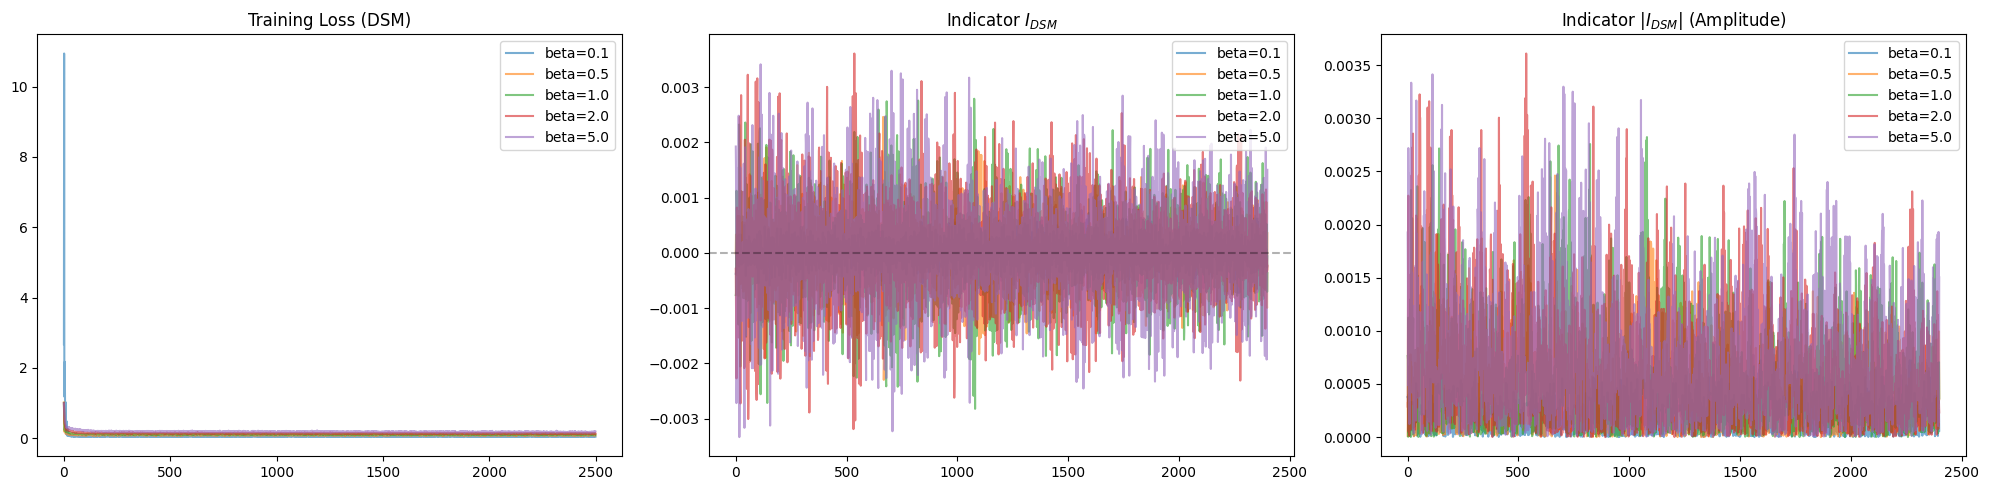

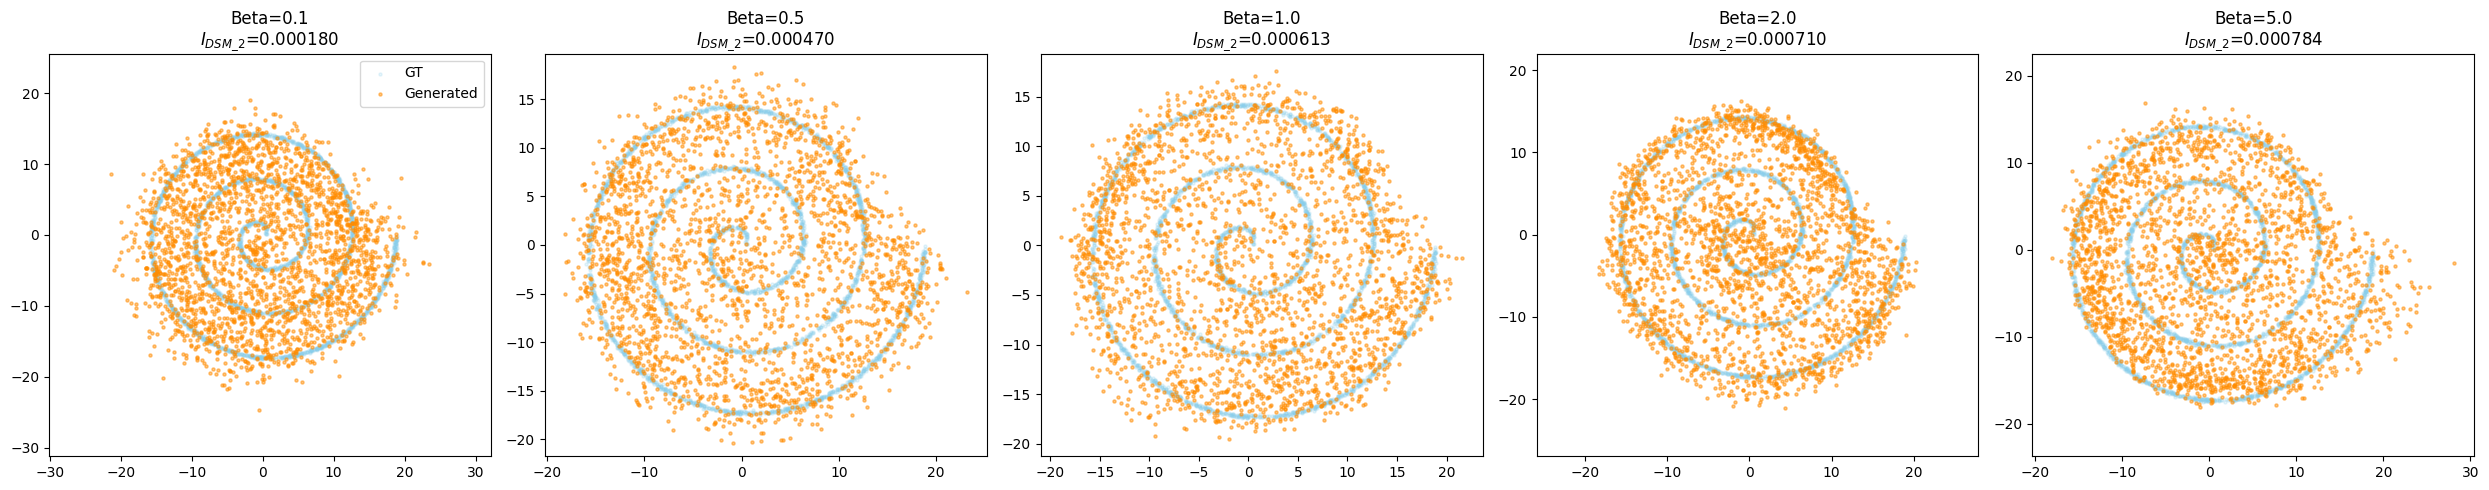

In [9]:
#### 0413 新增 idsm_2的數據
import numpy as np

# 1. 繪製訓練曲線
fig, ax = plt.subplots(1, 3, figsize=(20, 5)) # 改為 1x3，增加一個子圖給 IDSM_2
for b in beta_list:
    res = all_results[b]
    
    # 計算 IDSM_2 序列（絕對值）
    idsm2_series = np.abs(res["idsm"])
    avg_idsm2 = np.mean(idsm2_series[100:]) # 避開初始波動後的平均
    
    # 繪圖
    ax[0].plot(res["loss"], label=f"beta={b}", alpha=0.6)
    ax[1].plot(res["idsm"][100:], label=f"beta={b}", alpha=0.6) 
    ax[2].plot(idsm2_series[100:], label=f"beta={b}", alpha=0.6) # 新增的絕對值曲線
    
    print(f"Beta {b}: Avg Loss = {res['avg_loss']:.4f}, "
          f"Avg IDSM = {res['avg_idsm']:.8f}, "
          f"Avg IDSM_2 (Abs) = {avg_idsm2:.8f}")

ax[0].set_title("Training Loss (DSM)"); ax[0].legend()
ax[1].set_title("Indicator $I_{DSM}$"); ax[1].legend()
ax[1].axhline(0, color='black', linestyle='--', alpha=0.3) # 增加 0 基準線
ax[2].set_title("Indicator $|I_{DSM}|$ (Amplitude)"); ax[2].legend()

plt.tight_layout()
plt.show()

# 2. 繪製生成結果圖 (這部分保持不變)
plt.figure(figsize=(25, 5))
for i, b in enumerate(beta_list):
    plt.subplot(1, 5, i+1)
    gen = all_results[b]["gen_data"]
    
    plt.scatter(gt_data[:, 0], gt_data[:, 1], color='skyblue', s=5, alpha=0.2, label='GT')
    plt.scatter(gen[:, 0], gen[:, 1], color='darkorange', s=5, alpha=0.5, label='Generated')
    
    plt.title(f"Beta={b}\n$I_{{DSM\_2}}$={np.mean(np.abs(all_results[b]['idsm'][100:])):.6f}")
    plt.axis('equal')
    if i == 0: plt.legend()

plt.tight_layout()
plt.show()

Beta 0.1: Avg Loss = 0.0521, Avg IDSM = 0.00078387
Beta 0.5: Avg Loss = 0.0861, Avg IDSM = 0.00002767
Beta 1.0: Avg Loss = 0.1114, Avg IDSM = 0.00002173
Beta 2.0: Avg Loss = 0.1409, Avg IDSM = 0.00001835
Beta 5.0: Avg Loss = 0.1858, Avg IDSM = 0.00000490


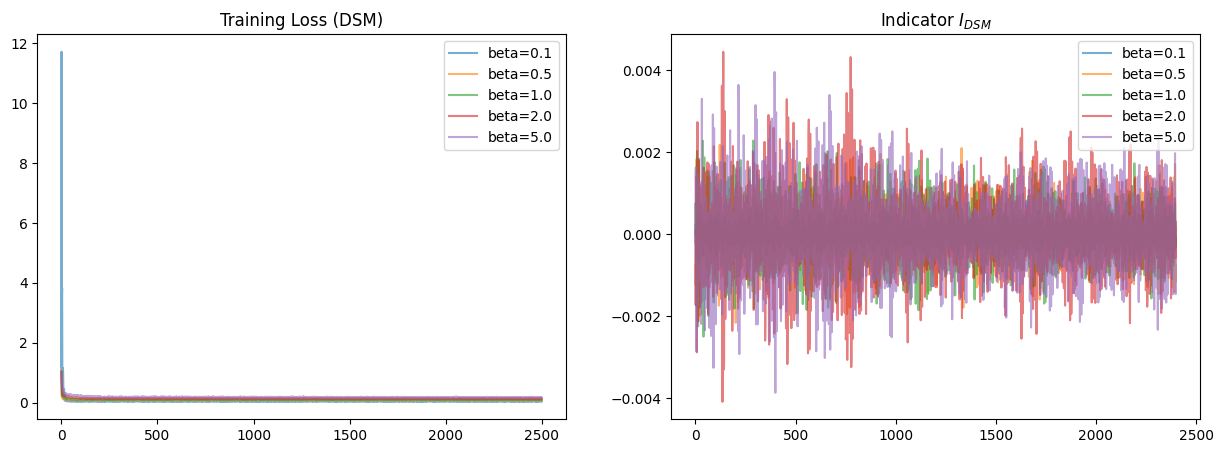

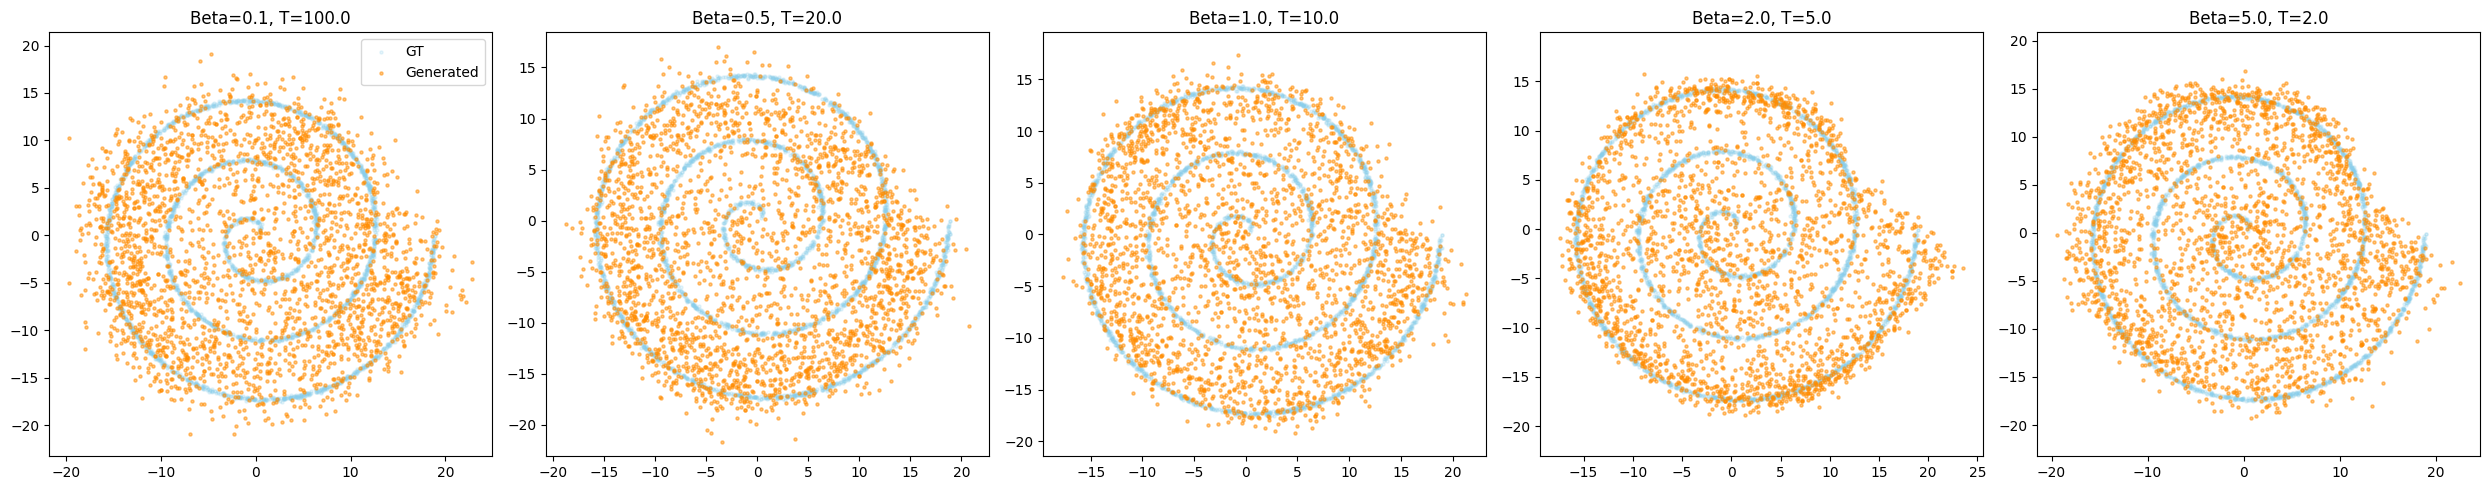

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for b in beta_list:
    res = all_results[b]
    ax[0].plot(res["loss"], label=f"beta={b}", alpha=0.6)
    ax[1].plot(res["idsm"][100:], label=f"beta={b}", alpha=0.6) # 避開初始波動
    print(f"Beta {b}: Avg Loss = {res['avg_loss']:.4f}, Avg IDSM = {res['avg_idsm']:.8f}")

ax[0].set_title("Training Loss (DSM)"); ax[0].legend()
ax[1].set_title("Indicator $I_{DSM}$"); ax[1].legend()
plt.show()

plt.figure(figsize=(25, 5))
for i, b in enumerate(beta_list):
    plt.subplot(1, 5, i+1)
    gen = all_results[b]["gen_data"]
    
    plt.scatter(gt_data[:, 0], gt_data[:, 1], color='skyblue', s=5, alpha=0.2, label='GT')
    plt.scatter(gen[:, 0], gen[:, 1], color='darkorange', s=5, alpha=0.5, label='Generated')
    
    plt.title(f"Beta={b}, T={target_constant/b:.1f}")
    plt.axis('equal')
    if i == 0: plt.legend()

plt.tight_layout()
plt.show()

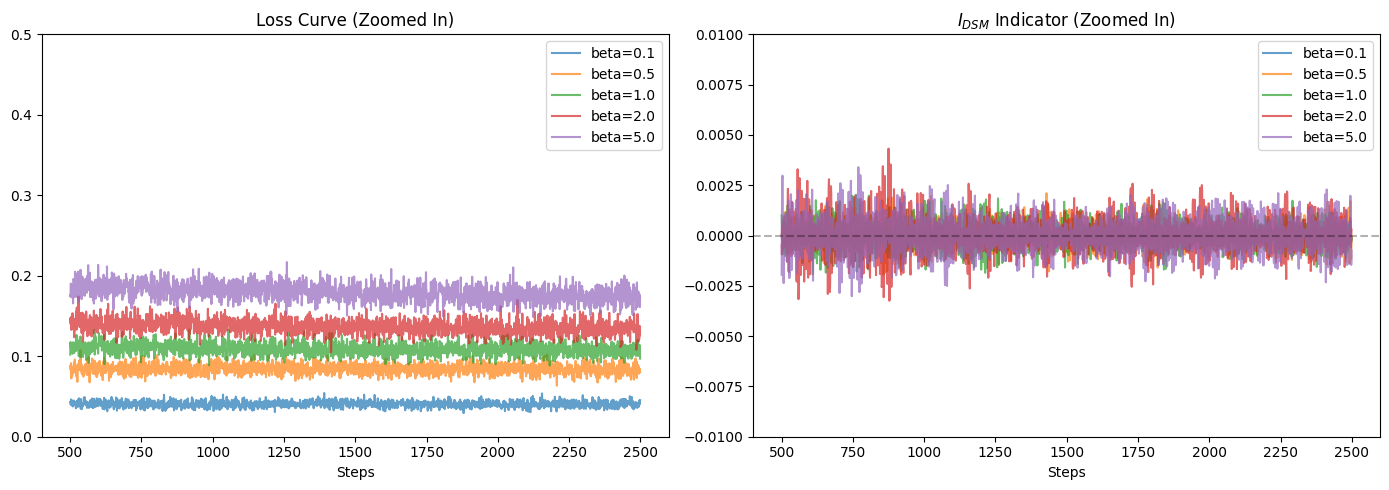

In [8]:
plt.figure(figsize=(14, 5))

# --- 局部放大 Loss Curve ---
plt.subplot(1, 2, 1)
start_step = 500  # 跳過前 500 步
for b in beta_list:
    data = all_results[b]["loss"][start_step:]
    plt.plot(range(start_step, start_step + len(data)), data, label=f"beta={b}", alpha=0.7)

plt.ylim(0, 0.5) # << 手動設定 y 軸上限，根據你的數據調整 (例如 0.1 ~ 0.5)
plt.title("Loss Curve (Zoomed In)")
plt.xlabel("Steps")
plt.legend()

# --- 局部放大 I_DSM Curve ---
plt.subplot(1, 2, 2)
for b in beta_list:
    data = all_results[b]["idsm"][start_step:]
    plt.plot(range(start_step, start_step + len(data)), data, label=f"beta={b}", alpha=0.7)

plt.ylim(-0.01, 0.01) # << 重要！設定在 0 附近的範圍，才能看出誰比較接近 0
plt.axhline(0, color='black', linestyle='--', alpha=0.3) # 畫一條 0 的基準線
plt.title("$I_{DSM}$ Indicator (Zoomed In)")
plt.xlabel("Steps")
plt.legend()

plt.tight_layout()
plt.show()